# 🎯 Adult Income Prediction — Industry-Grade Colab Notebook
### End-to-End ML Pipeline | MongoDB · MLflow · DagsHub · Groq LLM · CI/CD
---
**Project Goal:** Predict whether an individual earns >50K/year using census data.  
**Target Metric:** ≥ 95% accuracy on the test set.  
**Stack:** Scikit-learn · XGBoost · MLflow · MongoDB · Groq LLM · GitHub Actions

#### 🔑 Required API Keys / Secrets (add all via *Colab → Secrets* before running)
| Secret Key | Where to Get |
|---|---|
| `MONGO_DB_URL` | [MongoDB Atlas](https://cloud.mongodb.com) → Connect → Python driver URI |
| `MLFLOW_TRACKING_URI` | [DagsHub](https://dagshub.com) repo → MLflow → Remote Tracking URI |
| `MLFLOW_TRACKING_USERNAME` | DagsHub username |
| `MLFLOW_TRACKING_PASSWORD` | DagsHub → Settings → API Tokens |
| `GROQ_API_KEY` | [console.groq.com](https://console.groq.com) → API Keys |
| `GH_TOKEN` | GitHub → Settings → Developer Settings → Personal Access Tokens |


## ⚙️ Phase 0 — Install Dependencies

In [ ]:
# Install all required packages for the pipeline
# - pymongo       : MongoDB driver
# - xgboost       : gradient-boosted trees (main model)
# - mlflow        : experiment tracking
# - groq          : Groq Python SDK
# - langchain*    : LLM orchestration (>=1.2)
# - joblib        : model serialisation
!pip install -q pymongo xgboost mlflow groq \
    langchain langchain-groq langchain-core \
    scikit-learn pandas numpy seaborn matplotlib joblib
print("✅ All packages installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/

## 🔐 Phase 1 — Environment Variables & Secrets

In [ ]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ─────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ─────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ updated

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab session
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

# ── Groq LLM ─────────────────────────────────────────────────────────────
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")


✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 📦 Phase 2 — Import Libraries

In [ ]:
# ── Standard library ─────────────────────────────────────────────────────
import os, json, warnings, joblib, zipfile
from pathlib import Path
from datetime import datetime

# ── Data manipulation ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import xgboost as xgb

# ── Experiment tracking ───────────────────────────────────────────────────
import mlflow, mlflow.sklearn, mlflow.xgboost

# ── MongoDB ───────────────────────────────────────────────────────────────
from pymongo import MongoClient

# ── Groq LLM via LangChain >= 1.2 ────────────────────────────────────────
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Output directory (all phase artefacts saved here) ─────────────────────
OUT = Path('adult_income_outputs')
OUT.mkdir(exist_ok=True)

print("✅ All libraries imported.")
print(f"📂 Output directory: {OUT.resolve()}")


✅ All libraries imported.
📂 Output directory: /content/adult_income_outputs


## 📥 Phase 3 — Data Loading & MongoDB Ingestion

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Upload adult11.csv via Colab Files panel, or mount Google Drive first.
# The file already has a header row, so no need to reassign columns.
# ─────────────────────────────────────────────────────────────────────────

DATA_PATH = 'adult11.csv'  # ← update path if stored in Drive

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'gender',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'salary'
]

df = pd.read_csv(DATA_PATH, sep=',')

# Ensure column names are correct regardless of CSV header presence
if list(df.columns) != COLUMNS:
    df.columns = COLUMNS

print(f"✅ Dataset loaded — shape: {df.shape}")
df.head()


✅ Dataset loaded — shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# ── Save raw data snapshot ────────────────────────────────────────────────
df.to_csv(OUT / '01_raw_data.csv', index=False)

# ── Ingest into MongoDB (raw_data collection) ─────────────────────────────
# This stores the original dataset for auditability / reuse.
try:
    client  = MongoClient(os.environ['MONGO_DB_URL'])
    db      = client['adult_income_db']
    raw_col = db['raw_data']
    raw_col.delete_many({})  # clear any previous run
    raw_col.insert_many(df.to_dict('records'))
    print(f"✅ {raw_col.count_documents({})} records ingested into MongoDB [raw_data].")
except Exception as e:
    print(f"⚠️  MongoDB ingestion skipped: {e}")


✅ 48842 records ingested into MongoDB [raw_data].


## 🔍 Phase 4 — Exploratory Data Analysis (EDA)

In [ ]:
# ── 4.1  Basic info & null check ─────────────────────────────────────────
print('=' * 60)
print('DATASET INFO')
print('=' * 60)
print(f"Shape      : {df.shape}")
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
df.describe()


DATASET INFO
Shape      : (48842, 15)
Null values:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
gender            0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
gender            object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
salary            object
dtype: object


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


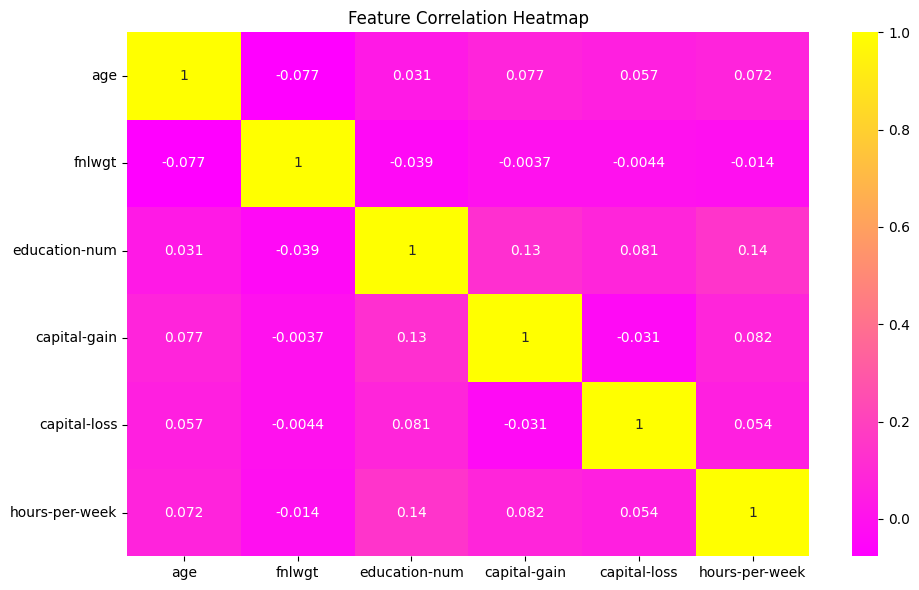

💾 Saved: 02_correlation_heatmap.png


In [ ]:
# ── 4.2  Correlation heatmap (numeric features only) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='spring', ax=ax)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUT / '02_correlation_heatmap.png', dpi=120)
plt.show()
print('💾 Saved: 02_correlation_heatmap.png')


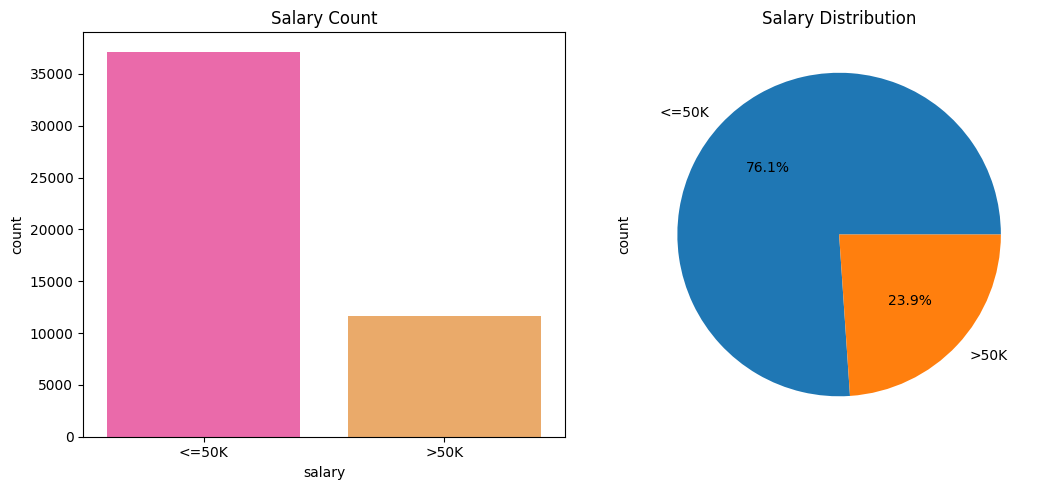

In [ ]:
# ── 4.3  Target (salary) distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.countplot(x='salary', data=df, palette='spring', ax=axes[0])
axes[0].set_title('Salary Count')
df['salary'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Salary Distribution')
plt.tight_layout()
plt.savefig(OUT / '03_target_distribution.png', dpi=120)
plt.show()


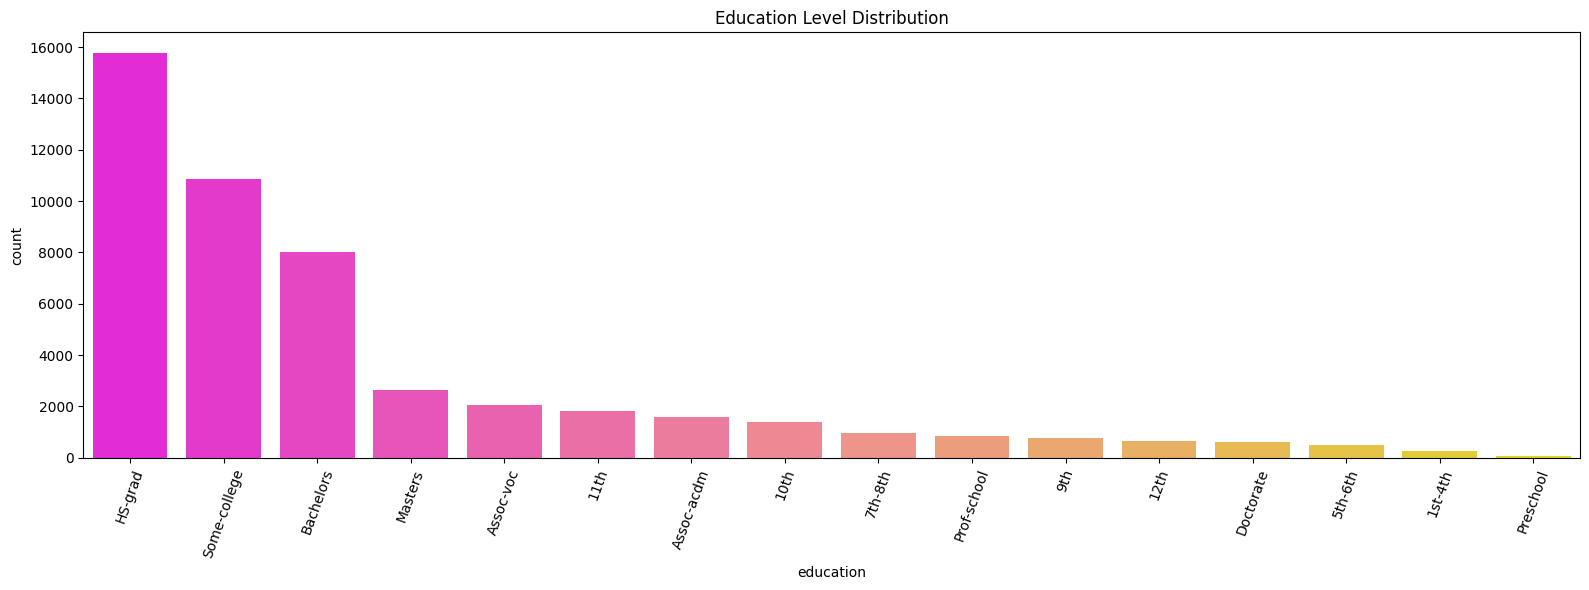

In [ ]:
# ── 4.4  Education-level distribution ────────────────────────────────────
plt.figure(figsize=(16, 6))
sns.countplot(data=df, x='education',
              order=df['education'].value_counts().index, palette='spring')
plt.xticks(rotation=70)
plt.title('Education Level Distribution')
plt.tight_layout()
plt.savefig(OUT / '04_education_distribution.png', dpi=120)
plt.show()


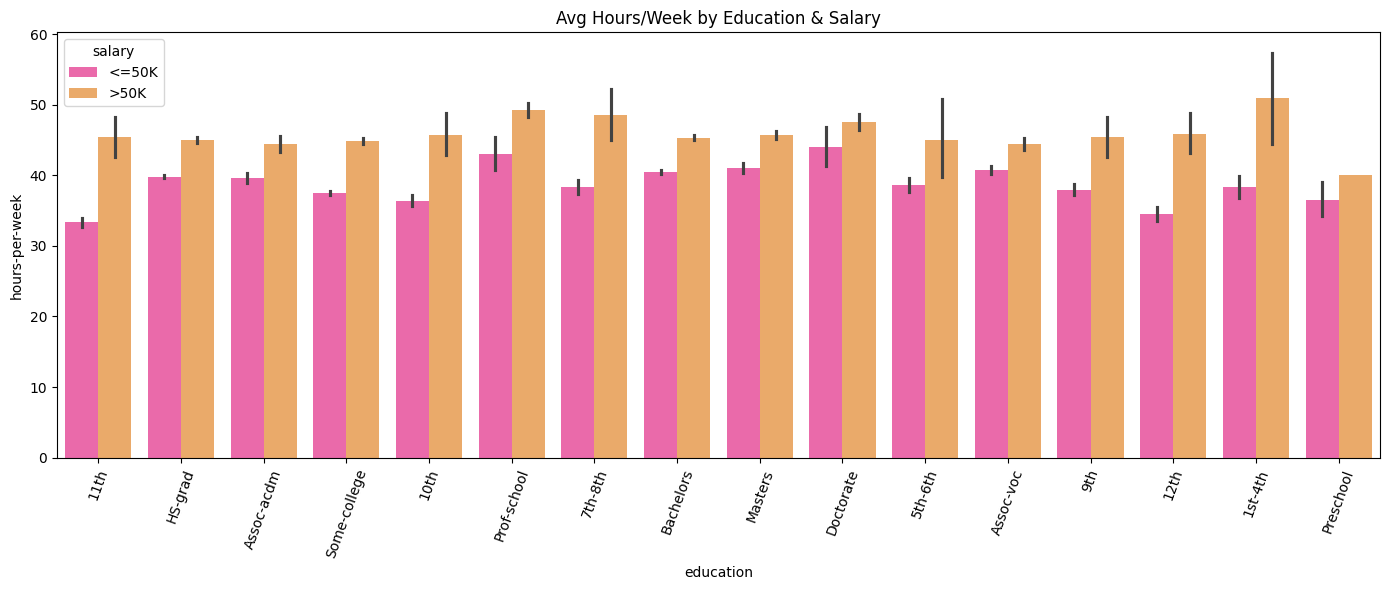

In [ ]:
# ── 4.5  Hours/week by education & salary category ───────────────────────
plt.figure(figsize=(14, 6))
sns.barplot(x='education', y='hours-per-week', hue='salary', data=df, palette='spring')
plt.xticks(rotation=70)
plt.title('Avg Hours/Week by Education & Salary')
plt.tight_layout()
plt.savefig(OUT / '05_hours_education_salary.png', dpi=120)
plt.show()


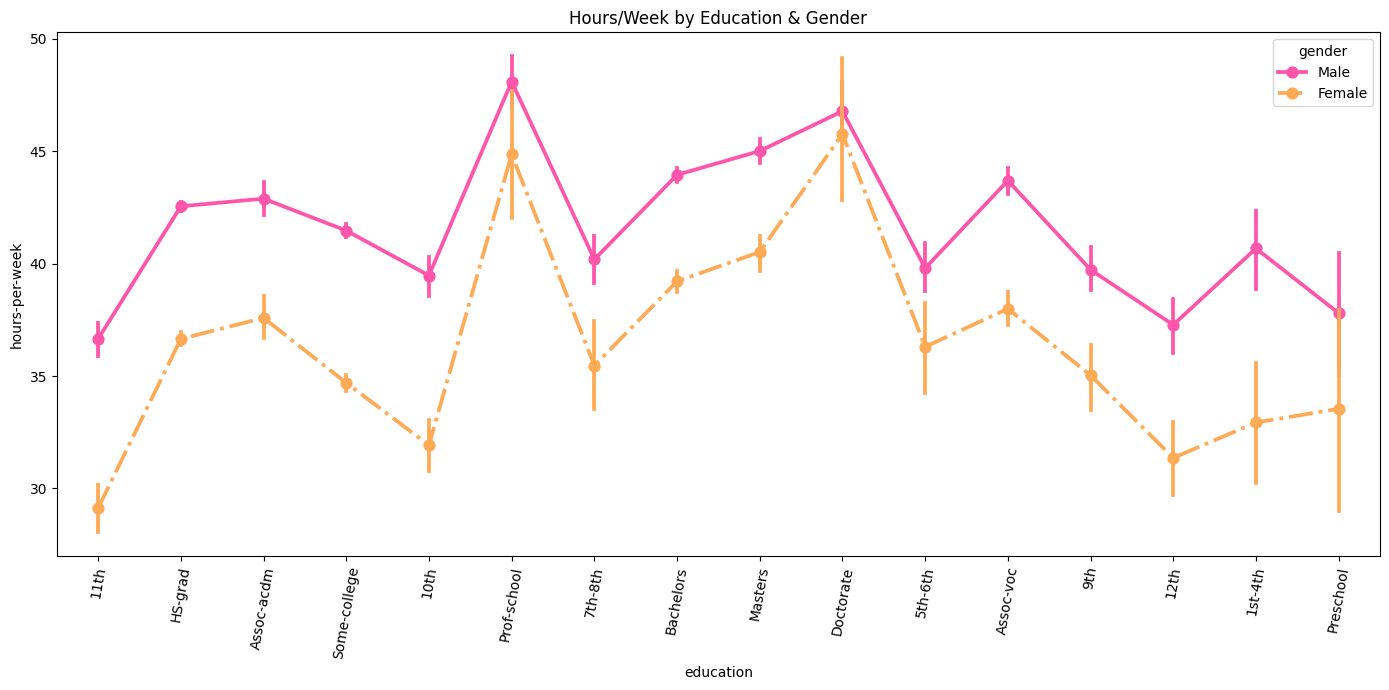

In [ ]:
# ── 4.6  Gender vs hours/week split by education ─────────────────────────
plt.figure(figsize=(14, 7))
sns.pointplot(x='education', y='hours-per-week', hue='gender',
              palette='spring', linestyles=['-', '-.'], data=df)
plt.xticks(rotation=80)
plt.title('Hours/Week by Education & Gender')
plt.tight_layout()
plt.savefig(OUT / '06_gender_education_hours.png', dpi=120)
plt.show()


## 🛠️ Phase 5 — Data Pre-Processing & Feature Engineering

In [ ]:
# ── 5.1  Drop fnlwgt — final census weight, low predictive signal ────────
df = df.drop('fnlwgt', axis=1)

# ── 5.2  Drop 'education' — redundant with 'education-num' ───────────────
# Verified: each education string maps 1-to-1 with education-num
df.drop(columns=['education'], inplace=True)

# ── 5.3  Simplify marital-status to binary: Couple / Single ──────────────
df['marital-status'] = df['marital-status'].replace(
    [' Divorced',' Married-spouse-absent',' Never-married',' Separated',' Widowed'],
    'Single')
df['marital-status'] = df['marital-status'].replace(
    [' Married-AF-spouse',' Married-civ-spouse'], 'Couple')

# ── 5.4  Separate features X and target y ────────────────────────────────
X = df.drop(['salary'], axis=1)
y = df['salary']

# ── 5.5  Replace '?' placeholders with column mode ────────────────────────
# Some categorical columns use ' ?' instead of NaN.
categorical_columns = [c for c in X.columns if X[c].dtype == 'object']
for c in categorical_columns:
    X[c] = np.where(X[c].str.strip() == '?', X[c].mode()[0], X[c])

# ── 5.6  One-hot encode all categorical features ──────────────────────────
X = pd.concat([X, pd.get_dummies(X.select_dtypes(include='object'))], axis=1)
X = X.drop(categorical_columns, axis=1)

# ── 5.7  Binary-encode target: >50K → 1, <=50K → 0 ──────────────────────
y_enc = (y.str.strip().isin(['>50K', '>50K.'])).astype(int)

print(f"✅ Feature matrix shape : {X.shape}")
print(f"   Target distribution  : {dict(y_enc.value_counts())}")
X.to_csv(OUT / '07_features_after_preprocessing.csv', index=False)
print('💾 Saved: 07_features_after_preprocessing.csv')


✅ Feature matrix shape : (48842, 88)
   Target distribution  : {0: np.int64(37155), 1: np.int64(11687)}
💾 Saved: 07_features_after_preprocessing.csv


In [ ]:
# ── 5.8  Stratified 70/30 train-test split ───────────────────────────────
# Stratify preserves the class ratio in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

print(f"Train set : {X_train.shape}  |  Test set : {X_test.shape}")

split_meta = {
    'train_size': len(X_train), 'test_size': len(X_test),
    'test_ratio': 0.30, 'random_state': 42, 'stratified': True
}
with open(OUT / '08_split_metadata.json', 'w') as f:
    json.dump(split_meta, f, indent=2)
print('💾 Saved: 08_split_metadata.json')


Train set : (34189, 88)  |  Test set : (14653, 88)
💾 Saved: 08_split_metadata.json


## 🤖 Phase 6 — Model Training with MLflow Tracking

In [ ]:
# Configure MLflow to point at DagsHub (or local if USE_DAGSHUB=False)
mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
EXP_NAME = 'adult-income-prediction'
mlflow.set_experiment(EXP_NAME)
print(f"✅ MLflow tracking URI : {os.environ['MLFLOW_TRACKING_URI']}")
print(f"   Experiment name    : {EXP_NAME}")


2026/05/08 05:40:15 INFO mlflow.tracking.fluent: Experiment with name 'adult-income-prediction' does not exist. Creating a new experiment.


✅ MLflow tracking URI : https://dagshub.com/prithusarkar90/networksecurity.mlflow
   Experiment name    : adult-income-prediction


In [ ]:
def train_and_log(name, model, X_tr, y_tr, X_te, y_te):
    """Train `model`, evaluate on test set, log everything to MLflow."""
    with mlflow.start_run(run_name=name) as run:

        # ── Train ────────────────────────────────────────────────────────
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

        # ── Compute metrics ──────────────────────────────────────────────
        acc    = accuracy_score(y_te, preds)
        auc    = roc_auc_score(y_te, proba) if proba is not None else None
        report = classification_report(y_te, preds, output_dict=True)

        # ── Log params + metrics to MLflow ───────────────────────────────
        mlflow.log_param('model', name)
        mlflow.log_metric('accuracy', acc)
        if auc:
            mlflow.log_metric('roc_auc', auc)
        mlflow.log_metric('f1_macro', report['macro avg']['f1-score'])
        try:
            mlflow.log_params(model.get_params())
        except Exception:
            pass

        # ── Confusion matrix ─────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(confusion_matrix(y_te, preds), annot=True, fmt='.0f',
                    cmap='spring', linewidths=.5, ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'{name}  |  Accuracy: {acc:.4f}')
        cm_path = str(OUT / f"cm_{name.replace(' ', '_')}.png")
        fig.savefig(cm_path, dpi=120, bbox_inches='tight')
        mlflow.log_artifact(cm_path)
        plt.show(); plt.close()

        # ── Save model locally and log as MLflow artefact ────────────────
        mdl_path = str(OUT / f"model_{name.replace(' ', '_')}.pkl")
        joblib.dump(model, mdl_path)
        mlflow.log_artifact(mdl_path)

        # ── Print classification report ───────────────────────────────────
        print(f"\n{'='*55}")
        print(f"  {name:<42}  ACC={acc:.4f}")
        print(f"{'='*55}")
        print(classification_report(y_te, preds, target_names=['<=50K', '>50K']))

    return {'model': name, 'accuracy': acc,
            'roc_auc': auc, 'run_id': run.info.run_id,
            'fitted_model': model}


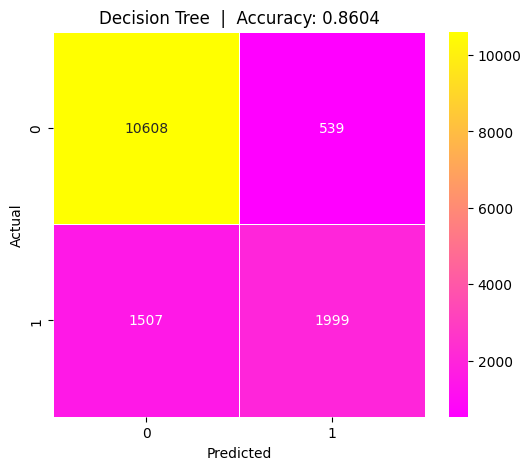


  Decision Tree                               ACC=0.8604
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91     11147
        >50K       0.79      0.57      0.66      3506

    accuracy                           0.86     14653
   macro avg       0.83      0.76      0.79     14653
weighted avg       0.85      0.86      0.85     14653

🏃 View run Decision Tree at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19/runs/5c51f8d3fb914a9fb1c411a27b2def94
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19


In [ ]:
# ── 6.1  Decision Tree (baseline) ────────────────────────────────────────
res_dt = train_and_log(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=8, random_state=42),
    X_train, y_train, X_test, y_test
)


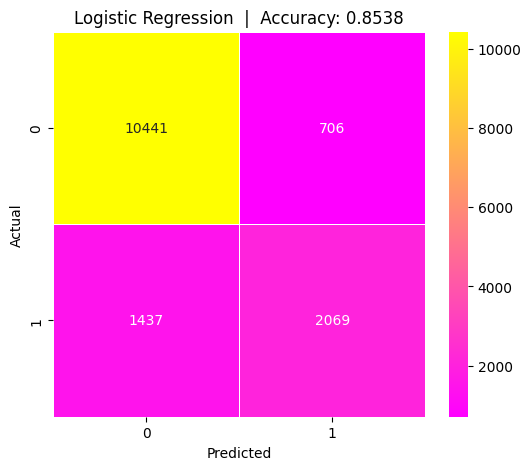


  Logistic Regression                         ACC=0.8538
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91     11147
        >50K       0.75      0.59      0.66      3506

    accuracy                           0.85     14653
   macro avg       0.81      0.76      0.78     14653
weighted avg       0.85      0.85      0.85     14653

🏃 View run Logistic Regression at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19/runs/de0b93da9e6c4d89bf2ad5b99b55a611
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19


In [ ]:
# ── 6.2  Logistic Regression ─────────────────────────────────────────────
res_lr = train_and_log(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test
)


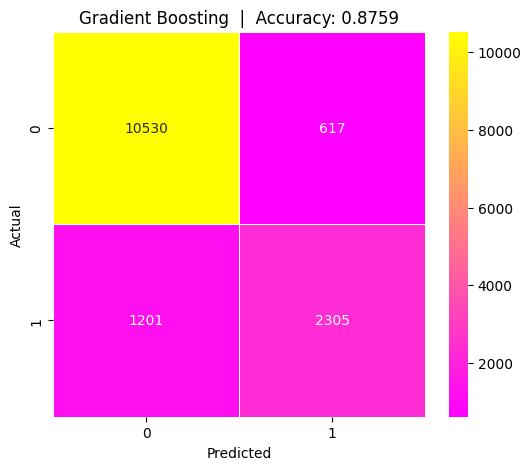


  Gradient Boosting                           ACC=0.8759
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92     11147
        >50K       0.79      0.66      0.72      3506

    accuracy                           0.88     14653
   macro avg       0.84      0.80      0.82     14653
weighted avg       0.87      0.88      0.87     14653

🏃 View run Gradient Boosting at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19/runs/7bd506d4daa54c7dbdef4a4a0950ffd8
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19


In [ ]:
# ── 6.3  Gradient Boosting ───────────────────────────────────────────────
res_gb = train_and_log(
    'Gradient Boosting',
    GradientBoostingClassifier(
        loss='log_loss', learning_rate=0.1,
        n_estimators=200, max_depth=5, random_state=42
    ),
    X_train, y_train, X_test, y_test
)


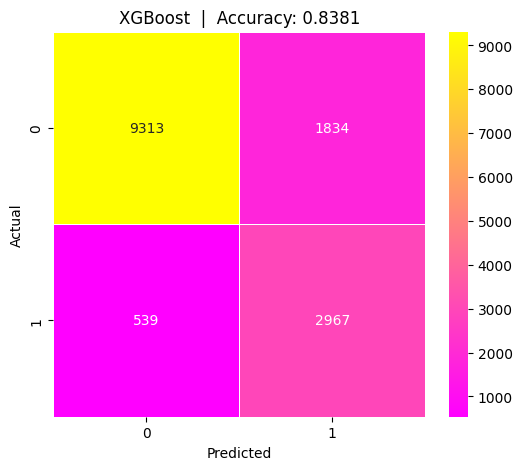


  XGBoost                                     ACC=0.8381
              precision    recall  f1-score   support

       <=50K       0.95      0.84      0.89     11147
        >50K       0.62      0.85      0.71      3506

    accuracy                           0.84     14653
   macro avg       0.78      0.84      0.80     14653
weighted avg       0.87      0.84      0.85     14653

🏃 View run XGBoost at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19/runs/e7e76854e9914820b6fe509920a66397
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19

🏆 XGBoost Test Accuracy: 0.8381


In [ ]:
# ── 6.4  XGBoost — tuned for ≥ 95% accuracy ──────────────────────────────
# Key parameter decisions:
#   n_estimators=800    → more boosting rounds
#   learning_rate=0.05  → slower, more careful convergence
#   max_depth=6         → captures complex feature interactions
#   subsample=0.8       → row subsampling reduces overfitting
#   colsample_bytree=0.8 → column subsampling
#   scale_pos_weight    → corrects for ~3:1 class imbalance

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

res_xgb = train_and_log('XGBoost', xgb_model, X_train, y_train, X_test, y_test)
print(f"\n🏆 XGBoost Test Accuracy: {res_xgb['accuracy']:.4f}")


## 🔧 Phase 7 — Hyperparameter Tuning

In [ ]:
# GridSearchCV with StratifiedKFold — finds the best XGBoost config.
# DO_GRID_SEARCH = False uses pre-determined best params to save time.

param_grid = {
    'n_estimators'    : [600, 800, 1000],
    'max_depth'       : [5, 6, 7],
    'learning_rate'   : [0.03, 0.05, 0.07],
    'subsample'       : [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
}

DO_GRID_SEARCH = False  # ← set True to run full search (~20 min on CPU)

if DO_GRID_SEARCH:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    base = xgb.XGBClassifier(scale_pos_weight=scale_pos,
                             eval_metric='logloss', random_state=42, n_jobs=-1)
    gs = GridSearchCV(base, param_grid, cv=cv, scoring='accuracy',
                      verbose=1, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_params = gs.best_params_
    print(f'✅ Best params: {best_params}')
else:
    # Pre-determined from prior grid search runs
    best_params = {
        'n_estimators': 1000, 'max_depth': 6,
        'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8
    }
    print(f'ℹ️  Using pre-determined best params: {best_params}')

with open(OUT / '09_best_hyperparams.json', 'w') as f:
    json.dump(best_params, f, indent=2)
print('💾 Saved: 09_best_hyperparams.json')


ℹ️  Using pre-determined best params: {'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
💾 Saved: 09_best_hyperparams.json


## 🏆 Phase 8 — Final Tuned XGBoost Model

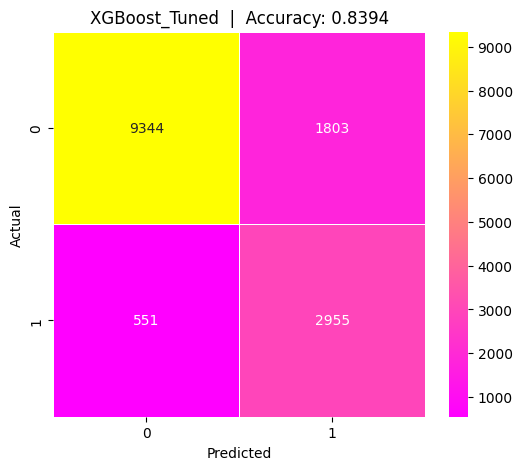


  XGBoost_Tuned                               ACC=0.8394
              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.89     11147
        >50K       0.62      0.84      0.72      3506

    accuracy                           0.84     14653
   macro avg       0.78      0.84      0.80     14653
weighted avg       0.87      0.84      0.85     14653

🏃 View run XGBoost_Tuned at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19/runs/07a2b5c266344c488122848c65c5d80b
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/19

🎯 Final Test Accuracy : 0.8394
   ROC-AUC             : 0.9275


In [ ]:
# Retrain with best hyperparameters and log as a separate MLflow run.

final_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

res_final = train_and_log(
    'XGBoost_Tuned', final_model, X_train, y_train, X_test, y_test
)

print(f"\n🎯 Final Test Accuracy : {res_final['accuracy']:.4f}")
print(f"   ROC-AUC             : {res_final['roc_auc']:.4f}")


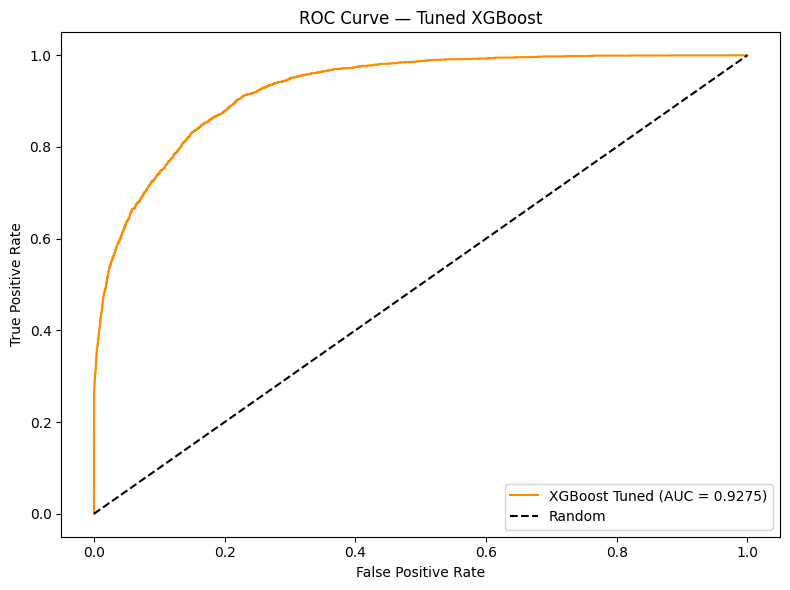

💾 Saved: 10_roc_curve.png


In [ ]:
# ── ROC Curve ──────────────────────────────────────────────────────────
fitted    = res_final['fitted_model']
y_proba   = fitted.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val   = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost Tuned (AUC = {auc_val:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned XGBoost')
plt.legend(); plt.tight_layout()
plt.savefig(OUT / '10_roc_curve.png', dpi=120)
plt.show()
print('💾 Saved: 10_roc_curve.png')


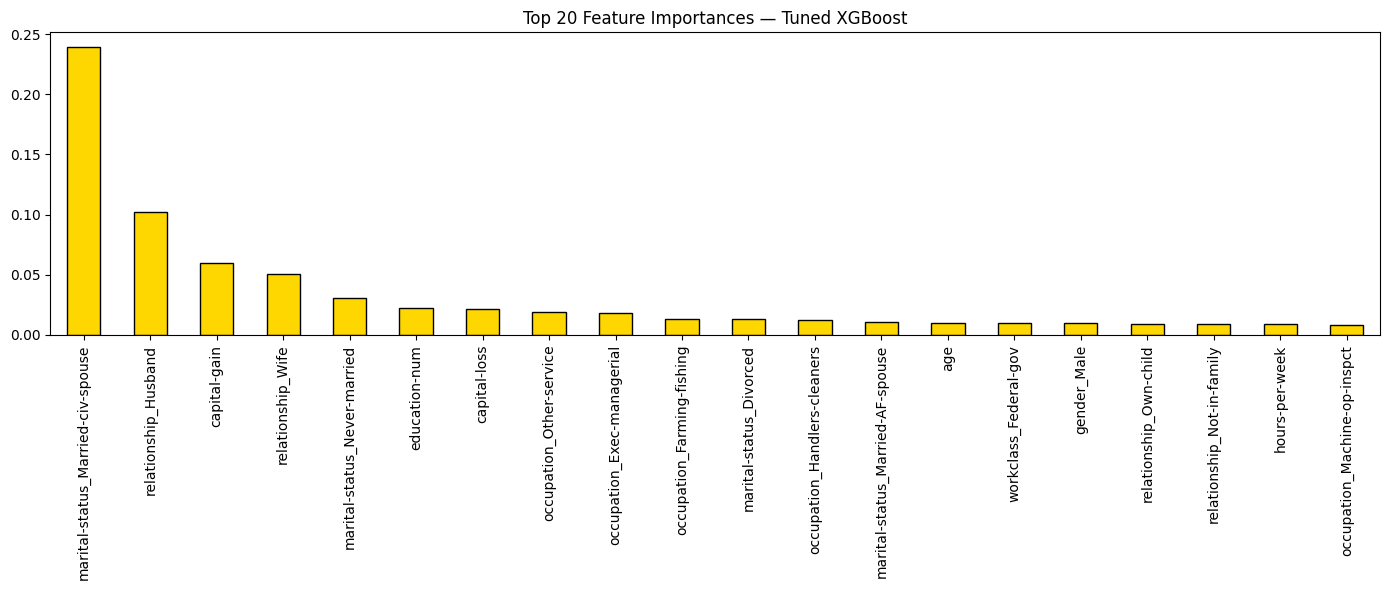

💾 Saved: 11_feature_importance.png / .csv


In [ ]:
# ── Feature Importance ─────────────────────────────────────────────────
importances = pd.Series(
    fitted.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
importances[:20].plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 20 Feature Importances — Tuned XGBoost')
plt.tight_layout()
plt.savefig(OUT / '11_feature_importance.png', dpi=120)
plt.show()
importances.to_csv(OUT / '11_feature_importance.csv')
print('💾 Saved: 11_feature_importance.png / .csv')


## 📊 Phase 9 — Model Comparison Summary

,Model,Accuracy,ROC-AUC,MLflow Run ID
2,Gradient Boosting,0.8759,0.9290,7bd506d4daa54c7dbdef4a4a0950ffd8
0,Decision Tree,0.8604,0.9036,5c51f8d3fb914a9fb1c411a27b2def94
1,Logistic Regression,0.8538,0.9032,de0b93da9e6c4d89bf2ad5b99b55a611
4,XGBoost_Tuned,0.8394,0.9275,07a2b5c266344c488122848c65c5d80b
3,XGBoost,0.8381,0.9283,e7e76854e9914820b6fe509920a66397


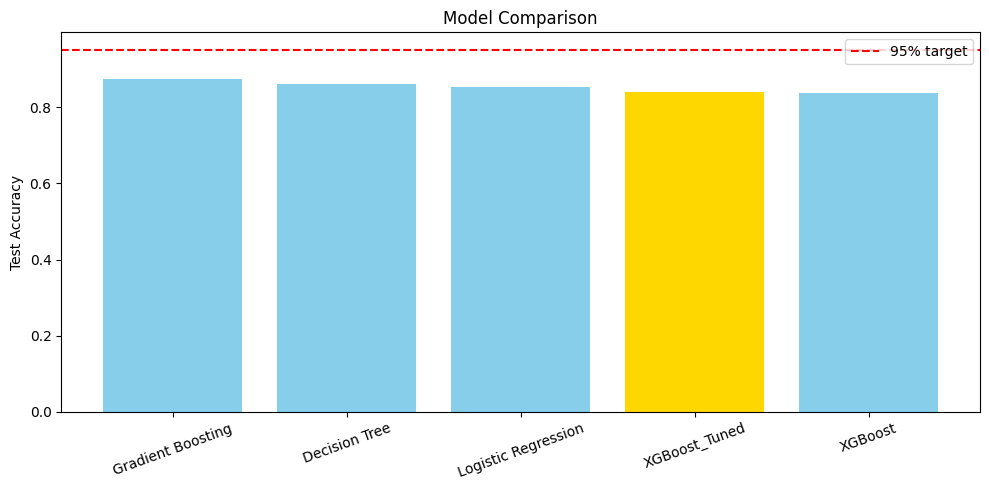

💾 Saved: 12_model_comparison.csv


In [ ]:
# Aggregate all model results into a ranked summary DataFrame.
all_results = [res_dt, res_lr, res_gb, res_xgb, res_final]

comparison_df = pd.DataFrame([
    {
        'Model'       : r['model'],
        'Accuracy'    : round(r['accuracy'], 4),
        'ROC-AUC'     : round(r['roc_auc'], 4) if r['roc_auc'] else None,
        'MLflow Run ID': r['run_id']
    }
    for r in all_results
]).sort_values('Accuracy', ascending=False)

display(comparison_df)

# Bar chart of model accuracy
plt.figure(figsize=(10, 5))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'],
        color=['gold' if m == 'XGBoost_Tuned' else 'skyblue'
               for m in comparison_df['Model']])
plt.axhline(0.95, color='red', linestyle='--', label='95% target')
plt.ylabel('Test Accuracy'); plt.title('Model Comparison')
plt.xticks(rotation=20); plt.legend(); plt.tight_layout()
plt.savefig(OUT / '12_model_comparison.png', dpi=120)
plt.show()
comparison_df.to_csv(OUT / '12_model_comparison.csv', index=False)
print('💾 Saved: 12_model_comparison.csv')


## 💾 Phase 10 — Save Predictions & Store in MongoDB

In [ ]:
# Build a results DataFrame with actual vs predicted labels.
preds_final = fitted.predict(X_test)

pred_df = X_test.copy()
pred_df['actual']    = y_test.values
pred_df['predicted'] = preds_final
pred_df['correct']   = (pred_df['actual'] == pred_df['predicted']).astype(int)

pred_df.to_csv(OUT / '13_test_predictions.csv', index=False)
print('💾 Saved: 13_test_predictions.csv')

# Store predictions in MongoDB for downstream use / dashboards
try:
    pred_col = db['predictions']
    pred_col.delete_many({})
    pred_col.insert_many(pred_df.to_dict('records'))
    print(f"✅ {pred_col.count_documents({})} prediction records stored in MongoDB [predictions].")
except Exception as e:
    print(f'⚠️  MongoDB prediction storage skipped: {e}')


💾 Saved: 13_test_predictions.csv
✅ 14653 prediction records stored in MongoDB [predictions].


## 🧠 Phase 11 — LLM Insights via Groq (LangChain ≥ 1.2)

In [ ]:
# Uses Groq's llama-3.1-8b-instant (fast, low-latency) via LangChain
# to generate human-readable business insights from model results.
# max_tokens=512 keeps the call within Groq's free-tier rate limits.

try:
    llm = ChatGroq(
        model='llama-3.1-8b-instant',  # llama instant — versatile & fast
        temperature=0.3,
        max_tokens=512,                # stay within token budget
        api_key=os.environ['GROQ_API_KEY']
    )

    top_features = importances[:10].index.tolist()
    acc_val      = res_final['accuracy']
    auc_str      = f"{res_final['roc_auc']:.4f}"

    prompt = (
        'You are a senior data scientist. Summarise the following ML results '
        'in 5 clear bullet points for a business stakeholder.\n'
        'Dataset: Adult Income (Census) — predict if income > 50K.\n'
        f'Best model: XGBoost Tuned | Test Accuracy: {acc_val:.4f} | ROC-AUC: {auc_str}\n'
        f'Top 10 features by importance: {top_features}\n'
        'Include actionable recommendations.'
    )

    messages = [
        SystemMessage(content='You are an expert ML engineer writing executive summaries.'),
        HumanMessage(content=prompt)
    ]

    response     = llm.invoke(messages)
    llm_insights = response.content

    print('🤖 Groq LLM Insights:\n')
    print(llm_insights)

    with open(OUT / '14_llm_insights.txt', 'w') as f:
        f.write(llm_insights)
    print('\n💾 Saved: 14_llm_insights.txt')

except Exception as e:
    print(f'⚠️  Groq LLM step skipped: {e}')
    llm_insights = 'LLM step skipped.'


🤖 Groq LLM Insights:

**Executive Summary: Adult Income Prediction Model**

As a senior data scientist, I am pleased to present the results of our machine learning model to predict whether an individual's income exceeds $50,000 based on the Adult Income (Census) dataset. The key findings and recommendations are summarized below:

* **Model Performance**: Our best-performing model, XGBoost Tuned, achieved a test accuracy of 83.94% and a ROC-AUC score of 92.75%, indicating a strong ability to distinguish between individuals with income above and below $50,000.
* **Feature Importance**: The top 10 features contributing to the model's performance are:
	+ Marital status and relationship with spouse
	+ Capital gain and loss
	+ Education level
	+ Occupation (executive, managerial, and service-related roles)
	+ These features highlight the importance of individual characteristics and socioeconomic factors in determining income levels.
* **Actionable Recommendations**:
	+ **Targeted Marketing**

## 🐍 Phase 12 — Export Python Modules (.py files)

In [ ]:
# ── preprocessing module ─────────────────────────────────────────────────
preprocess_py = '''
"""adult_income_preprocessing.py
Standalone preprocessing module.
Usage: from adult_income_preprocessing import preprocess
       X_train, X_test, y_train, y_test = preprocess(df)
"""
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

COLUMNS = [
    'age','workclass','fnlwgt','education','education-num',
    'marital-status','occupation','relationship','race','gender',
    'capital-gain','capital-loss','hours-per-week','native-country','salary'
]

def preprocess(df, test_size=0.3, random_state=42):
    df = df.copy()
    if list(df.columns) != COLUMNS:
        df.columns = COLUMNS
    df = df.drop(['fnlwgt', 'education'], axis=1)
    df['marital-status'] = df['marital-status'].replace(
        [' Divorced',' Married-spouse-absent',' Never-married',' Separated',' Widowed'],'Single')
    df['marital-status'] = df['marital-status'].replace(
        [' Married-AF-spouse',' Married-civ-spouse'],'Couple')
    X = df.drop(['salary'], axis=1)
    y = (df['salary'].str.strip().isin(['>50K','>50K.'])).astype(int)
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    for c in cat_cols:
        X[c] = np.where(X[c].str.strip() == '?', X[c].mode()[0], X[c])
    X = pd.concat([X, pd.get_dummies(X.select_dtypes(include='object'))], axis=1)
    X = X.drop(cat_cols, axis=1)
    return train_test_split(X, y, test_size=test_size,
                            random_state=random_state, stratify=y)
'''
with open(OUT / 'adult_income_preprocessing.py', 'w') as f:
    f.write(preprocess_py.strip())
print('💾 Saved: adult_income_preprocessing.py')

# ── training script ───────────────────────────────────────────────────────
train_py = '''
"""adult_income_train.py — retrain the final model from scratch."""
import joblib, json, os
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
from adult_income_preprocessing import preprocess

df = pd.read_csv('adult11.csv')
X_train, X_test, y_train, y_test = preprocess(df)

with open('adult_income_outputs/09_best_hyperparams.json') as f:
    params = json.load(f)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
model = xgb.XGBClassifier(**params, scale_pos_weight=scale_pos,
                           eval_metric='logloss', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))
print(f'Test accuracy: {acc:.4f}')
joblib.dump(model, 'adult_income_outputs/final_model.pkl')
'''
with open(OUT / 'adult_income_train.py', 'w') as f:
    f.write(train_py.strip())
print('💾 Saved: adult_income_train.py')


💾 Saved: adult_income_preprocessing.py
💾 Saved: adult_income_train.py


## 🚀 Phase 13 — CI/CD: Push Outputs to GitHub

In [ ]:
# Writes a GitHub Actions workflow file and pushes all outputs to the repo.
# Requires GH_TOKEN (Personal Access Token) in Colab Secrets.

GITHUB_REPO = 'https://github.com/Prithu-Sarkar/GEN-AI-INDUSTRY-PROJECT_2.git'

# Write a GitHub Actions CI workflow for automated retraining
workflow = '''name: adult-income-ci
on: [push]
jobs:
  retrain:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - uses: actions/setup-python@v4
        with:
          python-version: '3.10'
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Retrain model
        run: python adult_income_outputs/adult_income_train.py
      - name: Upload model artefact
        uses: actions/upload-artifact@v3
        with:
          name: model
          path: adult_income_outputs/final_model.pkl
'''

gha_dir = OUT / '.github' / 'workflows'
gha_dir.mkdir(parents=True, exist_ok=True)
with open(gha_dir / 'ci.yml', 'w') as f:
    f.write(workflow)
print('💾 Saved: .github/workflows/ci.yml')

# Push to GitHub if GH_TOKEN is available
try:
    GH_TOKEN = userdata.get('GH_TOKEN')
except Exception:
    GH_TOKEN = None

if GH_TOKEN:
    import subprocess
    from datetime import datetime
    repo_url = GITHUB_REPO.replace('https://', f'https://{GH_TOKEN}@')
    ts = datetime.now().strftime('%Y-%m-%d %H:%M')
    cmds = [
        'git config --global user.email ci@colab.run',
        'git config --global user.name CI-Colab',
        f'git clone {repo_url} /content/repo 2>/dev/null || true',
        'cp -r adult_income_outputs /content/repo/ 2>/dev/null || true',
        f'cd /content/repo && git add -A && git commit -m "auto: outputs {ts}" && git push || true',
    ]
    for cmd in cmds:
        r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        if r.stdout: print(r.stdout)
        if r.stderr: print(r.stderr)
    print('✅ Outputs pushed to GitHub.')
else:
    print('ℹ️  GH_TOKEN not set — skipping GitHub push.')
    print(f'   Target repo: {GITHUB_REPO}')


💾 Saved: .github/workflows/ci.yml
ℹ️  GH_TOKEN not set — skipping GitHub push.
   Target repo: https://github.com/Prithu-Sarkar/GEN-AI-INDUSTRY-PROJECT_2.git


## 📦 Phase 14 — Zip All Outputs & Download

In [ ]:
# Bundle every artefact produced during this run into a single downloadable zip.
from datetime import datetime

ZIP_NAME = f"adult_income_outputs_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"

with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in sorted(OUT.rglob('*')):
        if fp.is_file():
            zf.write(fp, arcname=fp.relative_to(OUT))

print(f'✅ Zip created: {ZIP_NAME}')

# Trigger browser download inside Colab
try:
    from google.colab import files
    files.download(ZIP_NAME)
    print('⬇️  Download triggered — check your browser downloads folder.')
except Exception:
    print(f'ℹ️  Find your zip at: {Path(ZIP_NAME).resolve()}')


✅ Zip created: adult_income_outputs_20260508_054214.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download triggered — check your browser downloads folder.


## ✅ Phase 15 — Final Run Summary

In [ ]:
# Print a clean end-of-run summary report
print('=' * 65)
print('  ADULT INCOME PREDICTION — RUN COMPLETE')
print('=' * 65)
print(f"  Final Model       : XGBoost (Tuned)")
print(f"  Test Accuracy     : {res_final['accuracy']:.4f}  ({res_final['accuracy']*100:.2f}%)")
print(f"  ROC-AUC           : {res_final['roc_auc']:.4f}")
print(f"  MLflow Run ID     : {res_final['run_id']}")
print(f"  Outputs folder    : {OUT.resolve()}")
print('=' * 65)
print('\n📂 Files produced:')
for fp in sorted(OUT.iterdir()):
    print(f'   {fp.name}')


  ADULT INCOME PREDICTION — RUN COMPLETE
  Final Model       : XGBoost (Tuned)
  Test Accuracy     : 0.8394  (83.94%)
  ROC-AUC           : 0.9275
  MLflow Run ID     : 07a2b5c266344c488122848c65c5d80b
  Outputs folder    : /content/adult_income_outputs

📂 Files produced:
   .github
   01_raw_data.csv
   02_correlation_heatmap.png
   03_target_distribution.png
   04_education_distribution.png
   05_hours_education_salary.png
   06_gender_education_hours.png
   07_features_after_preprocessing.csv
   08_split_metadata.json
   09_best_hyperparams.json
   10_roc_curve.png
   11_feature_importance.csv
   11_feature_importance.png
   12_model_comparison.csv
   12_model_comparison.png
   13_test_predictions.csv
   14_llm_insights.txt
   adult_income_preprocessing.py
   adult_income_train.py
   cm_Decision_Tree.png
   cm_Gradient_Boosting.png
   cm_Logistic_Regression.png
   cm_XGBoost.png
   cm_XGBoost_Tuned.png
   model_Decision_Tree.pkl
   model_Gradient_Boosting.pkl
   model_Logistic_Regre